## Set

In [1]:
# imports
# Statistics

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from ipywidgets import interact

# Regular Expression searching
import re
# Plotting
import matplotlib as mlp
import matplotlib.pyplot as plt #plotting and html plots
plt.style.use('dark_background')
#plt.style.use('default')
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import pandas as pd
import numpy as np
# Suite2p for TIFF file analysis
from suite2p.run_s2p import run_s2p, default_ops
# interact with system
import os
import sys

# Used for Popups
import tkinter as tk

import nest_asyncio

# for progress bar support
from tqdm import tqdm



# statistics
import scipy
import math


# Mesc file analysis
import h5py
from tifffile import tifffile, imread
import pathlib


# add root directory to be able to import packages
# todo: make all packages installable so they can be called/imported by environment
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

from utils.calcium import calcium

C:\Users\mauls\AppData\Local\Temp\ipykernel_40648\3535396220.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
# Init Directories and Notebook settings
#root_dir = "D:\\Steffen_Experiments"  
root_dir = "F:\\Steffen_Experiments"  
#root_dir = "D:\\Rodrigo"
#root_dir = "D:\\Other_Rodrigo_Data"

# Pearson and histogram plot and save
mean_threshold = 0.1
std_threshold = 0.15

year_list = ["2021", "2022"]


# Collor pallet for plotting
colors = mlp.colormaps["rainbow"](range(0,300))


%matplotlib inline
#%matplotlib tk
%autosave 180
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

Autosaving every 180 seconds


In [3]:
# Helper functions
def load_all(root_dir, animal_ids=["all"], generate=False, regenerate=False, units="single", delete=False):
    """
    Loads animal data from the specified root directory for the given animal IDs.

    Parameters:
    - root_dir (string): The root directory path where the animal data is stored.
    - animal_ids (list, optional): A list of animal IDs to load. Default is ["all"].
    - generate (bool, optional): If True, generates new session data. Default is False.
    - regenerate (bool, optional): If True, regenerates existing session data. Default is False.
    - units (string, optional): Specifies the units. Default is "single".
    - delete (bool, optional): If True, deletes session data. Default is False.

    Returns:
    - animals_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    """
    animal_ids = get_directories(root_dir)
    animals_dict = {}

    # Search for animal_ids
    for animal_id in animal_ids:
        if animal_id in animal_ids or animal_ids[0] == "all":
            sessions_path = os.path.join(root_dir, animal_id)
            sessions = get_directories(sessions_path)
            yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")
            animal = Animal(yaml_file_name)
            # Search for 2P Sessions
            for session in sessions:
                animal.get_session_data(session, generate=generate, regenerate=regenerate, units=units, delete=delete)
            animals_dict[animal_id] = animal
    return animals_dict

def filter_animals(animal_dict, filters = []):
    """
    Filters the animal dictionary based on the specified filters.

    Parameters:
    - animal_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    - filters (list, optional): A list of filters to apply. Default is an empty list.

    Returns:
    - filtered_animal_dict (dict): A dictionary containing filtered animal IDs as keys and corresponding Animal objects as values.
    """
    filtered_animal_dict = animal_dict
    for filter in filters:
        tmp_animal_dict = {}
        for animal_id, animal in filtered_animal_dict.items():
            if filter == animal_id:
                tmp_animal_dict[animal_id] = animal
                continue
            if animal.year == filter: # cohort_year
                tmp_animal_dict[animal_id] = animal
                continue
            if filter == "male" or filter == "female":
                tmp_animal_dict[animal_id] = animal
                continue
        filtered_animal_dict = tmp_animal_dict
    return filtered_animal_dict

def get_age_range(animal_dict):
    """
    Retrieves the minimum and maximum age range from the given animal dictionary.

    Parameters:
    - animal_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.

    Returns:
    - min_age (int): The minimum age value found among all animals.
    - max_age (int): The maximum age value found among all animals.
    """
    ages_list = []
    min_age = float('inf')
    max_age = 0
    for animal_id, animal in animal_dict.items():
        ages_list.append(animal.pdays)
        min_age = min(animal.pdays) if min(animal.pdays) < min_age else min_age
        max_age = max(animal.pdays) if max(animal.pdays) > max_age else max_age
    unique_sorted_ages = np.unique(ages_list)
    unique_sorted_ages.sort() 
    return unique_sorted_ages, min_age, max_age

def sliding_window(arr, k):
    """
    Generate sliding windows of size k over an array.

    Args:
        arr (list): The input array.
        k (int): The size of the sliding window.

    Yields:
        list: A sliding window of size k.

    Returns:
        None: If the length of the array is less than k.
    """
    n = len(arr)
    if n < k:
        return None
    window = arr[:k]
    yield window
    for i in range(k, n):
        window = np.append(window[1:], arr[i])
        yield window

def sliding_mode(arr, k):
    """
    Compute the mode for each sliding window of size k over an array.

    Args:
        arr (list): The input array.
        k (int): The size of the sliding window.

    Returns:
        list: A list of mode values for each sliding window.
    """
    modes = []
    for window in sliding_window(arr, k):
        mode, count = scipy.stats.mode(window)
        modes.append(mode[0])
    return modes

def sliding_mean_std(arr, k):
    """
    Compute the sliding window mean and standard deviation of an array.

    Parameters:
    arr (array-like): Input array.
    k (int): Window size.

    Returns:
    list: A list of tuples containing the mean and standard deviation of each window.
    """
    num_windows = len(arr)-k+1
    mean_stds = np.zeros([num_windows, 2])
    for num, window in enumerate(sliding_window(arr, k)):
        mean_stds[num, 0] = np.mean(window)
        mean_stds[num, 1] = np.std(window)
    return np.array(mean_stds)

def split_array(arr, batch_size):
    """
    Splits an array into multiple arrays with batch size.

    Parameters:
        arr (list): The array to be split.
        batch_size (int): The batch size.

    Returns:
        list: A list of sub-arrays where each sub-array has the specified batch size.
    """
    if batch_size == "all":
        batch_size = len(arr)
    else:
        batch_size = int(batch_size)
    return [arr[i:i+batch_size] for i in range(0, len(arr), batch_size)]

### Popups
def yes_no_q(Question):
    """
    Displays a popup window with a yes/no question and returns the user's answer.

    Args:
        Question (str): The question to display in the popup window.

    Returns:
        bool: True if the user clicked "Yes", False if the user clicked "No".
    """
    def on_button_click(button_text):
        global result
        result = button_text
        root.destroy()

    root = tk.Tk()

    label = tk.Label(root, text=Question)
    label.pack()

    button1 = tk.Button(root, text="Yes", command=lambda: on_button_click("Yes"))
    button1.pack()

    button2 = tk.Button(root, text="No", command=lambda: on_button_click("No"))
    button2.pack()

    root.mainloop()

    return True if result=="Yes" else False

#### directory, file search
def dir_exist_create(directory):
    """
    Checks if a directory exists and creates it if it doesn't.

    Parameters:
    dir (str): Path of the directory to check and create.

    Returns:
    None
    """
    # Check if the directory exists
    if not os.path.exists(directory):
        # Create the directory
        os.makedirs(directory)

def del_present_file(directory):
    """
    Deletes a file if it exists.

    Parameters:
    file_location (str): Path of the file to delete.

    Returns:
    None
    """
    # check if the file exists
    if os.path.exists(directory):
        # delete the file
        os.remove(directory)

def get_directories(directory):
    """
    Returns a list of directories in the specified folder path.

    Args:
        folder_path (str): The path of the folder to get the directories from.

    Returns:
        list: A list of directory names.
    """
    # Get a list of directories in the specified folder
    # Filter the list to include only directories (excluding the "figures" directory)
    directories = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name)) and name!="figures"]
    return directories

def get_files(directory, ending="all"):
    """
    This function returns a list of files in a given directory. 
    If an ending is specified, it returns only the files that end with the specified ending.
    
    :param directory: The directory to search for files.
    :type directory: str
    :param ending: The file ending to filter by. Default value is "all", which returns all files.
    :type ending: str
    :return: A list of files in the given directory. If an ending is specified, only files that end with the specified ending are returned.
    :rtype: list
    """
    files_list = [name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))]
    if ending != "all":
        files_list_with_ending = []
        for file in files_list:
            if file.endswith(ending):
                files_list_with_ending.append(file)
        return files_list_with_ending
    return files_list

def search_file(directory, filename):
    """
    This function searches for a file with a given filename within a specified directory and its subdirectories.

    :param directory: The directory in which to search for the file.
    :type directory: str
    :param filename: The name of the file to search for.
    :type filename: str
    :return: The full path of the file if found, otherwise returns the string "Not found".
    :rtype: str
    """
    for root, dirs, files in os.walk(directory):
        if filename in files:
            return os.path.join(root, filename)
    return None

In [4]:
class Cell:
    def __init__(self, parent):
        self.parent = parent
        
class Analyzer:
    mean_threshold = 0.1
    std_threshold = 0.15
    correct_mean = 0.007428876195354758


    def __init__(self, animals={}):
        self.animals = animals
        self.good = self.bad = self.evaluate_datasets_count()

    def good_mean_std(self, mean, std):
        return True if mean < Analyzer.mean_threshold or std > Analyzer.std_threshold else False

    def evaluate_datasets_count(self, animals=None):
        good = 0
        bad = 0
        if animals == None:
            animals = self.animals
        for animal_id, animal in animals.items():
            try:
                for session_id, session in animal.sessions.items():
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                    mean = np.mean(corr_matrix.flatten())
                    std = np.std(corr_matrix.flatten())
                    if self.good_mean_std(mean, std):
                        good += 1
                    else:
                        bad += 1
            except:
                print("Error while evaluation datasets")
        return good, bad

    def lin_reg(self, data):
        length = np.arange(len(data))
        lin_reg = scipy.stats.linregress(length, data)
        return lin_reg

    def get_linreg_slope_intercept(self, data):
        linreg = self.lin_reg(data)
        return linreg.slope, linreg.intercept

    def cont_mean_increase(self, mean_stds, num_bad_means = 30*60*1.5, 
                       num_not_bad_means=30*60*0.7):
        """
        Check if the mean of the data increases for 1.5 minutes without a 0.7 minutes break (30fps)

        Args:
            data (numpy.ndarray): A 2D numpy array containing mean and standard deviation values.

        Returns:
            bool: True if the mean values are within the threshold, False otherwise.
        """
        bad = False
        reason = ""
        bad_mean_counter = 0
        maybe_not_bad_counter = 0
        old_mean = mean_stds[0][0]
        min_std = np.min(mean_stds[:, 1])

        for pos, mean_std in enumerate(mean_stds[1:]):
            mean = mean_std[0]
            mean_diff = mean-old_mean
            mean_diff -=  min_std/(1/(abs(mean_diff/mean)))#7000
            old_mean = mean
            if math.isnan(mean): #mean > max_plausible_mean or :
                bad = True
                reason = "nan"
                break
            if mean_diff > 0: #Analyzer.correct_mean + threshold:# or math.isnan(mean):
                bad_mean_counter += 1
            else:
                maybe_not_bad_counter += 1
                if maybe_not_bad_counter > num_not_bad_means:
                    bad_mean_counter = 0
                    maybe_not_bad_counter = 0

            if bad_mean_counter >= num_bad_means: # 1 minute wide window mean to high for 1 minute  
                bad = True
                reason = "num bad"
                break

        return bad, reason+" c: "+str(bad_mean_counter)+" not bad "+str(maybe_not_bad_counter)#, pos/30

    def all_stds_good(self, mean_stds, std_threshold = 2):
        """
        Check if the standard deviation of the data are within a certain threshold.

        Args:
            data (numpy.ndarray): A 2D numpy array containing mean and standard deviation values.

        Returns:
            bool: True if the standard deviation values are within the threshold, False otherwise.
        """
        bad = False
        # Check if the cell is active
        if np.nanmean(mean_stds[:, 1]) < Analyzer.correct_std/4: 
            bad = True
            return bad
        ## Check if cells are to noisy
        for mean_std in mean_stds:
            std = mean_std[1]
            if math.isnan(std) or abs(std) > Analyzer.correct_std + std_threshold:
                bad = True
                break
        return bad

    def geldrying(self, mean_stds, minutes=0.7):
        """
        Geldrying detection
        Check if the mean and standard deviation (std not used!!!!!!) of the data are within a certain threshold.

        Args:
            data (numpy.ndarray): A 2D numpy array containing mean and standard deviation values.

        Returns:
            bool: True if the standard deviation values are within the threshold, False otherwise.
        """
        bad, reason = self.cont_mean_increase(mean_stds, num_not_bad_means=30*60*minutes) #TODO: improve good bad detection currently only for geldrying used
        #if not bad:
        #    bad = self.all_stds_good(mean_stds)
        return bad, reason

class Session:
    def __init__(self, animal_id, session_id, generate=False, regenerate=False, units="all", delete=False, age=None, session_date=None) -> None:
        print(f"Loading session: {animal_id} {session_id}")
        self.animal_id = animal_id
        self.session_id = session_id
        self.session_date = session_date
        self.session_dir = os.path.join(root_dir, animal_id, session_id, Animal.dir_)
        self.calcium_object = None

        self.age = age
        
        self.mesc_data_path = self.get_mesc_data_path()
        self.session_parts = self.get_session_parts()  #TODO: WARNING! units could not start at 0
        self.tiff_data_paths = self.get_tiff_data_paths(generate=generate, regenerate=regenerate, units=units, delete=delete)
        self.s2p_folder_paths = self.get_s2p_folder_paths(generate=generate, regenerate=regenerate, units=units, delete=delete)

        self.cabincorr_data_paths = self.get_cabincorr_data_paths(generate=generate, regenerate=regenerate, units=units)
        #TODO: load suite2p files? how is RAM?
        #TODO: implement cabincorr functions for filtering correct data
        #self.corr_mean, self.corr_std = self.get_corr_mean_std()
        print(f"Finished {animal_id}: {session_id}")

    def get_mesc_data_path(self):
        # Search for MESC file names needed for TIFF creation
        files_list = get_files(self.session_dir, ending="mesc")
        for file_name in files_list:
            #TODO: Pipeline to get mesc_data_path not perfect
            if re.search("S1", file_name) == None and re.search("S2", file_name) == None and re.search("S3", file_name) == None:
                continue
            else:
                self.mesc_data_path = os.path.join(self.session_dir, file_name)
                return self.mesc_data_path
        return None

    def get_list_of_session_parts(self, file_name):
        session_parts = file_name.split(".")[0].split("_")[-1].split("-")
        return [session for session in session_parts if session[0]=="S"]
    
    def get_session_parts(self, file_name = None):
        session_parts_list = []
        if file_name == None:
            file_name = self.mesc_data_path
        else:
            session_parts_list = self.get_list_of_session_parts(file_name)
        
        tiff_session_parts = []
        tiff_files_list = get_files(self.session_dir, ending="tiff")
        for tiff_file_name in tiff_files_list:
            tiff_session_parts += self.get_list_of_session_parts(tiff_file_name)

        self.session_parts = list(np.unique(session_parts_list + tiff_session_parts))

        if file_name == None:
            self.session_parts = []

        return self.session_parts

    def get_tiff_data_paths(self, generate=False, regenerate=False, units="all", delete=False):

        tiff_data_paths = []
        self.tiff_data_paths = []
        if regenerate:
            if units == "single":
                for unit in self.session_parts:
                    tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=unit, delete=delete))
            else:
                tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=units, delete=delete))
            return tiff_data_paths
            
        files_list = get_files(self.session_dir, ending="tiff")
        for file_name in files_list:
            tiff_data_paths.append(os.path.join(self.session_dir, file_name))
        
        self.tiff_data_paths = tiff_data_paths

        if generate:
            if units == "single":
                for unit in self.session_parts:
                    tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=unit, delete=delete))
            else:
                tiff_data_paths.append(self.generate_tiff_from_mesc(regenerate=regenerate, units=units, delete=delete))
            return np.unique(tiff_data_paths).tolist()
        return tiff_data_paths 

    def generate_tiff_from_mesc(self, units="all", delete=False, regenerate=False):
        if isinstance(units, str):
            units = [units]

        if units[0] == "all":
            tiff_file_name = mesc_file_name.replace('.mesc','.tif')
            units = self.get_session_parts()
        else:
            tiff_file_name = os.path.join(self.session_dir, f"{self.animal_id}_{self.session_id}_{Animal.dir_}_")
            for unit in units:
                tiff_file_name += unit + "-"
            tiff_file_name = tiff_file_name[:-1] + ".tiff"
        
            
        if tiff_file_name not in self.tiff_data_paths or regenerate:
            mesc_file_name = self.mesc_data_path

            if mesc_file_name == None:
                print("No MESC file found")
            else:
                # merging all mescs tiff
                print("Merging Mesc to Tiff...")
                

                sess_list = []
                for unit in units:
                    temp = unit.replace("S",'')
                    temp = 'MUnit_'+str(int(temp)-1) #TODO: error prone method, because units not equall to number of session
                    print ("session loaded: ", temp)
                    sess_list.append(temp)

                data = []
                with h5py.File(mesc_file_name, 'r') as file:
                    #
                    for sess in sess_list:
                        print ("processing: ", sess)
                        temp = file['MSession_0'][sess]['Channel_0'][()]
                        print ("    data loaded size: ", temp.shape)
                        data.append(temp)
                data = np.vstack(data)
                print(data.shape)

                tifffile.imwrite(tiff_file_name, data)
                if delete:
                    os.remove(mesc_file_name)
                print("Finished generating TIFF from MESC data.")
        else:
            print(".mesc -> .tiff file already done... skipping conversion...")

        return tiff_file_name

    def get_s2p_folder_paths(self, generate=False, regenerate=False, units="all", delete=False):
        self.s2p_folder_paths = []

        if regenerate:
            self.run_suite2p(regenerate=regenerate, units=units, delete=delete)

        s2p_folder_paths = get_directories(os.path.join(self.session_dir, "tif"))
        for folder_name in s2p_folder_paths:
            self.s2p_folder_paths.append(os.path.join(self.session_dir, "tif", folder_name))
        
        #FIXME: Check if this still working
        if units == "all":
            suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p")
            fluoresence_path = search_file(suite2p_folder, "F.npy")
            if fluoresence_path != None:
                self.s2p_folder_paths.append(suite2p_folder)
            elif generate:
                self.run_suite2p(regenerate=regenerate, units=units, delete=delete)
        elif units == "single":
            for unit in self.session_parts:
                suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p") + unit
                fluoresence_path = search_file(suite2p_folder, "F.npy")
                if fluoresence_path != None:
                    self.s2p_folder_paths.append(suite2p_folder)
                elif generate:
                    if units == "single":
                        for unit in self.session_parts:
                            self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)
        elif generate:
            self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)
        return np.unique(self.s2p_folder_paths).tolist()

    """def get_s2p_folder_paths(self, generate=False, regenerate=False, units="all", delete=False):
        self.s2p_folder_paths = []

        if generate and regenerate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)


        s2p_folder_paths = get_directories(os.path.join(self.session_dir, "tif"))
        for folder_name in s2p_folder_paths:
            self.s2p_folder_paths.append(os.path.join(self.session_dir, "tif", folder_name))
        
        for unit in self.session_parts:
            suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p") + unit
            fluoresence_path = search_file(suite2p_folder, "F.npy")
            if fluoresence_path != None:
                self.s2p_folder_paths.append(suite2p_folder)
            else:
                if generate and not regenerate:
                    if units == "single":
                        for unit in self.session_parts:
                            self.run_suite2p(regenerate=regenerate, units=unit, delete=delete)
        return np.unique(self.s2p_folder_paths).tolist()"""

    def run_suite2p(self, regenerate=False, units="all", delete=False):
        save_folder="tif\\suite2p"
        tiff_file_name = f"{self.animal_id}_{self.session_id}_{Animal.dir_}"

        if units == "single":
            units = self.session_parts

        #TODO: code below is present multiple times. Create function
        if units != "all":
            if isinstance(units, str):
                units = [units]
            for unit in units:                
                save_folder=save_folder + "_" + unit
                tiff_file_name += "_" + unit
        else:
            for unit in self.session_parts:
                tiff_file_name += "_" + unit

        tiff_file_name += ".tiff"
        dir_exist_create(os.path.join(self.session_dir, save_folder))

        current_fluoresence_data_path = search_file(os.path.join(self.session_dir, save_folder), "F.npy")

        if current_fluoresence_data_path != None and not regenerate:
            return current_fluoresence_data_path
        
        data_path = os.path.join(self.session_dir, tiff_file_name)

        if data_path not in self.tiff_data_paths:
            print(f"Failed to run Suite2P \n No Tiff found: {data_path}")
            return None    

        
        print("Starting Suite2p...")
        
        # set your options for running
        ops = default_ops() # populates ops with the default options
        ops['fs'] = 30 # sampling rate of recording, determines binning for cell detection
        #ops['batch_size'] = 200 # we will decrease the batch_size in case low RAM on computer
        #ops['threshold_scaling'] = 2.0 # we are increasing the threshold for finding ROIs to limit the number of non-cell ROIs found (sometimes useful in gcamp injections)
        #ops['tau'] = 1.25 # timescale of gcamp to use for deconvolution

        # provide an h5 path in 'h5py' or a tiff path in 'data_path'
        # db overwrites any ops (allows for experiment specific settings)
        db = {
            'look_one_level_down': False, # whether to look in ALL subfolders when searching for tiffs
            'data_path': [self.session_dir], # a list of folders with tiffs 
                                    # (or folder of folders with tiffs if look_one_level_down is True, or subfolders is not empty)
            'save_folder': save_folder,
            #'nimg_init': 500,      # Can create errors... how many frames to use to compute reference image for registration
            'tiff_list': [tiff_file_name],
            'allow_overlap': False,  #extract signals from pixels which belong to two ROIs. By default, any pixels which belong to two ROIs (overlapping pixels) are excluded from the computation of the ROI trace.
            'delete_bin': False,    # delete binary files afterwards
            'keep_movie_raw': True, # keep the binary file of the non-registered frames
            'reg_tif': True,        # write the registered binary to tiff files
            'move_bin': True,      # If True and ops['fast_disk'] is different from ops[save_disk], the created binary file is moved to ops['save_disk']
            'save_disk': os.path.join(self.session_dir, save_folder)
            #'combined': False      # combine results across planes in separate folder “combined” at end of processing.
            }
        # run one experiment
        opsEnd = run_s2p(ops=ops, db=db)
        self.s2p_folder_paths.append(os.path.join(self.session_dir, save_folder, "plane0"))
        if delete:
            print("Removing Tiff...")
            os.remove(data_path)
        print("Finished Suite2p.")

    def get_cabincorr_data_paths(self, generate=False, regenerate=False, units="all"):
        self.cabincorr_data_paths = []

        if regenerate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_cabincorr(regenerate=regenerate, units=unit)

        s2p_dirs = self.get_s2p_folder_paths()
        
        for s2pdir in s2p_dirs:
            cabincorr_file_path = search_file(s2pdir, Animal.cabincorr_file_name)
            if cabincorr_file_path != None:
                self.cabincorr_data_paths.append(cabincorr_file_path)

        if generate:
            if units == "single":
                for unit in self.session_parts:
                    self.run_cabincorr(regenerate=regenerate, units=unit)
            else:
                self.run_cabincorr(regenerate=regenerate, units=units)
        return self.cabincorr_data_paths
        
    def run_cabincorr(self, regenerate=False, units="all"):
        #TODO: create cabincorr package
        suite2p_folder = os.path.join(self.session_dir, "tif", "suite2p")

        if units != "all":
            if isinstance(units, str):
                units = [units]
            for unit in units:                
                suite2p_folder = suite2p_folder + "_" + unit

        current_cabincorr_data_path = search_file(suite2p_folder, Animal.cabincorr_file_name)

        if current_cabincorr_data_path != None and not regenerate:
            return current_cabincorr_data_path
        
        current_fluoresence_data_path = search_file(suite2p_folder, "F.npy")

        if current_fluoresence_data_path == None:
            print(f"Failed to run CaBinCorr \n No Suite2P data found: {suite2p_folder}")
            return None 

        print("Starting CaBinCorr...")
        #TODO: update code to newest version of cabincorr
        #Init
        c = calcium.Calcium()
        c.root_dir = root_dir
        c.data_dir = os.path.join(suite2p_folder, "plane0")
        c.animal_id = self.animal_id 
        c.session = self.session_id
        c.detrend_model_order = 1
        c.recompute_binarization = False
        c.remove_ends = False
        c.detrend_filter_threshold = 0.001
        c.mode_window = 30*30
        c.percentile_threshold = 0.000001
        c.dff_min = 0.02

        #
        c.load_suite2p()

        #
        c.load_binarization()
        current_cabincorr_data_path = search_file(suite2p_folder, Animal.cabincorr_file_name)
        self.cabincorr_data_paths.append(current_cabincorr_data_path)
        #TODO: Save every other information in parameters maybe save whole c object? Also for multiple version of suite2p data?
        #Generate correlations
        #self.calcium_object = c
        return "Update to new CaBinCorr"
    
    def load_cabincorr_data(self, unit="all"):
        if unit != "all":
            for path in self.cabincorr_data_paths:
                try:
                    session_part = int(path.split("suite2p_S")[1].split("\\")[0])
                    if unit == session_part:
                        bin_traces_zip = np.load(path)
                except:
                    #TODO: create a better solution for filtering out folder without session path
                    continue
        else:
            bin_traces_zip = np.load(self.cabincorr_data_paths[0]) #TODO: fill give false results if the correct folder is not choosen
        return bin_traces_zip
    
    def load_corr_matrix(self):
        #TODO: change after cabincorr package is finished
        corr_file_names = ["allcell_correlation_array_upphase.npy", "allcell_correlation_array_filtered.npy"]
        for corr_file_name in corr_file_names:
            for s2p_folder in self.s2p_folder_paths:
                corr_matrix_path = search_file(s2p_folder, corr_file_name)
                if corr_matrix_path != None:
                    break
            if corr_matrix_path != None:
                    break
        corr_pval_matrix = np.load(corr_matrix_path) # 1D correlation matrix, 2D pvalues
        corr_matrix = corr_pval_matrix[:,:,0]
        pval_matrix = corr_pval_matrix[:,:,1]
        return corr_matrix, pval_matrix

    def load_cell(self):
        #TODO: update to new cabincorr version
        return None

class Animal:
    dir_ = r'002P-F'
    cabincorr_file_name = "binarized_traces.npz"
    
    def __init__(self, yaml_file_path) -> None:
        self.sessions = {}
        self.year, self.day_of_birth, self.animal_id, self.pdays, self.session_dates, self.session_names, self.sex = self.load_data(yaml_file_path)
        self.animal_dir = os.path.join(root_dir, self.animal_id)
        print(f"Loading animal: {self.animal_id}")

    def load_data(self, yaml_file_path):
        with open(yaml_file_path) as f:
            lines = f.readlines()
        pdays = []
        session_dates = []
        session_names = []
        skip = 0
        for num, line in enumerate(lines):
            if skip > 0:
                skip -= 1
                continue
            if "cohort_year" in line:
                cohort_year = int(lines[num+1].split("- ")[1])
            if "dob" in line:
                dob = line.split(": ")[1][1:-2].strip()
            if "name: D" in line:
                print(line)
                animal_id = line.split(": ")[1].strip()
            if "pdays" in line:
                pdays = self.get_array_from_text_list(lines[num+1:], "session_dates")
                pdays = [int(pday) for pday in pdays]
                skip = len(pdays)
            if "session_dates" in line:
                session_dates = self.get_array_from_text_list(lines[num+1:], "session_names")
                skip = len(session_dates)
            if "session_names" in line:
                session_names = self.get_array_from_text_list(lines[num+1:], "sex")
                skip = len(session_names)
            if "sex" in line:
                sex = line.split(": ")[1].strip()
        return cohort_year, dob, animal_id, pdays, session_dates, session_names, sex

    def get_array_from_text_list(self, text_list, stop_word = ""):
        """
        This function takes in a list of text strings and an optional stop word as arguments. It returns a filtered list of strings.
        
        :param text_list: A list of text strings to be filtered.
        :type text_list: list
        :param stop_word: An optional argument that specifies a word to stop the filtering process. Default is an empty string.
        :type stop_word: str
        :return: A filtered list of strings.
        :rtype: list
        """
        filtered_list = []
        for line in text_list:
            if stop_word not in line:
                value = line[1:].strip().replace("'", "")
                filtered_list.append(value)
            else:
                break
        return filtered_list

    def get_session_data(self, session_id, generate=False, regenerate=False, units="all", delete=False):
        yaml_file_index = self.session_names.index(session_id)
        session = Session(self.animal_id, session_id, generate=generate, regenerate=regenerate, 
                        units=units, delete=delete, age=self.pdays[yaml_file_index], 
                        session_date=self.session_dates[yaml_file_index])
        self.sessions[session_id] = session
        return session
           
    def get_overview(self):
        print("-----------------------------------------------")
        print(f"{self.animal_id} born: {self.day_of_birth} sex: {self.sex}")
        overview_df = pd.DataFrame(columns = ['session_name', 'date', 'P', 'suite2p_folder_paths'])#, 'duration [min]'])
        for session_id, session in self.sessions.items():
            overview_df.loc[len(overview_df)] = {'session_name': session_id, 'date': session.session_date, 'P':session.age, 'suite2p_folder_paths':session.s2p_folder_paths}
        print(overview_df)
        print("-----------------------------------------------")
        return overview_df

class Vizualizer:
    def __init__(self, animals={}, save_dir=root_dir):
        self.animals = animals
        self.save_dir = os.path.join(save_dir, "figures")
        dir_exist_create(self.save_dir)
        self.colors = mlp.colormaps["rainbow"](range(0,300))

    def add_animal(self, animal):
        self.animals[animal.animal_id] = animal

    def create_colorsteps(self, min_value, max_value, max_color_number=300):
        """
        This function calculates the number of color steps between a minimum and maximum value.
        
        :param min_value: The minimum value in the range.
        :type min_value: int or float
        :param max_value: The maximum value in the range.
        :type max_value: int or float
        :param max_color_number: The maximum number of colors to use, defaults to 250.
        :type max_color_number: int, optional
        :return: The number of color steps between the minimum and maximum values.
        :rtype: int
        """
        value_diff = max_value-min_value if max_value-min_value != 0 else 1
        return round(max_color_number/(value_diff))

    def plot_colorsteps_example(self):
        # Colorexample
        for num, c in enumerate(self.colors):
            plt.plot([num, num], color=c, linewidth=2)

        handles = []
        for age in [0, 15, 30, 50, 75, 100, 125, 150, 180, 200, 220, 240]:
                handles.append(Line2D([0], [0], color=colors[age], linewidth=2, linestyle='-', label=f"Age {age}"))

        plt.legend(handles=handles)
        plt.show()

        #### save figures
    
    def bursts(self, animal_id, session_id, fluoresence_type="raw", num_cells="all", unit_id="all", dpi=300, fps="30"):

        #TODO: insert possibility to filter for good cells?
        #is_cells_ids = np.where(calcium_object.iscell==1)[0]
        #is_not_cells_ids = np.where(calcium_object.iscell==0)[0]
        #num_is_cells = is_cells_ids.shape[0] #get is cells
        #calcium_object.plot_traces(calcium_object.F_filtered, np.arange(num_is_cells))
    

        #for s2p_folder in self.animals[animal_id].sessions[session].s2p_folder_paths:
        bin_traces_zip = self.animals[animal_id].sessions[session_id].load_cabincorr_data(unit=unit_id)
        fluorescence = bin_traces_zip[f"F_{fluoresence_type}"]
        self.traces(fluorescence, animal_id, session_id, unit_id, num_cells, dpi, fps)
        return fluorescence

    def traces(self, fluorescence, animal_id, session_id, unit_id="all", num_cells="all", fit_line=False, dpi=300, fps="30",
               xlabel=f"Frames ", 
               ylabel='Fluoresence based on Ca in Cell',
               title=f"Bursts from "):
        # plot fluorescence
        fluorescence = np.array(fluorescence)
        fluorescence = np.transpose(fluorescence) if len(fluorescence.shape)==2 else fluorescence
        plt.figure()
        plt.figure(figsize=(12, 7))
        if num_cells != "all":
            plt.plot(fluorescence[:, :num_cells])
        else:
            plt.plot(fluorescence)

        if unit_id!="all":
            file_name = f"{animal_id}_{session_id}_Unit_{unit_id}"
        else:
            file_name = f"{animal_id}_{session_id}"

        plt.title(title+f"{file_name}")
        plt.xlabel(xlabel+f"({fps} FPS)")
        plt.ylabel(ylabel)
        file_title = title.replace(" ", "_")

        if fit_line and len(fluorescence.shape)==1: #TODO: add to 2d data?
            #TODO: move calculations to Analyzer
            anz = Analyzer()
            slope, intercept = anz.get_linreg_slope_intercept(fluorescence)
            length = range(len(fluorescence))
            plt.plot(length, intercept+length*slope, color = "r")

        plt.savefig(os.path.join(self.save_dir, f"{file_title}{file_name}.png"),
                    dpi=dpi)
        plt.show()

    def save_rasters_fig(self, calcium_object, animal_id, session_id, unit_id="all"): #TODO: Update to classes
        #TODO: yes?
        show_rasters_savelocation = os.path.join(calcium_object.data_dir, "figures")
        show_rasters_savelocation_name = os.path.join(show_rasters_savelocation, "rasters.png")
        own_location_name = os.path.join(self.save_dir, f"Rasters_{animal_id}_{session_id}_Unit_{unit_id}.png")

        dir_exist_create(os.path.join(calcium_object.data_dir, "figures"))
        del_present_file(own_location_name)
        del_present_file(show_rasters_savelocation_name)

        calcium_object.show_rasters(save_image=True)

        #change picture location
        os.rename(show_rasters_savelocation_name, own_location_name)    

    def pearson_hist(self, animal_id, session_id, dpi=300, 
                                title = "Pearson Correlation and Histogram",
                                hist_title='Pearson Correlation Coefficient Histogram',
                                hist_xlabel="Coefficients combined in 0.1 size bins",
                                hist_ylabel="Number of coefficients in bin",
                                facecolor="tab:blue"):
        
        # Create a figure and two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        corr_matrix, pval_matrix = self.animals[animal_id].sessions[session_id].load_corr_matrix()

        # First subplot
        sns.heatmap(corr_matrix, annot=False, cmap='YlGnBu', ax=ax1)
        ax1.set_xlabel("Neuron id")
        ax1.set_ylabel("Neuron id")
        ax1.set_title('Pearson Correlation Matrix')

        # Second subplot
        hist_data = corr_matrix if isinstance(corr_matrix, np.ndarray) else corr_matrix.to_numpy()
        sns.histplot(data=hist_data.flatten(), binwidth=0.1, ax=ax2, facecolor=facecolor)
        ax2.set_title(hist_title)
        ax2.set_xlabel(hist_xlabel)
        ax2.set_ylabel(hist_ylabel)
        plt.savefig(os.path.join(self.save_dir, title),
                    dpi=dpi)
        plt.show()
        return corr_matrix, pval_matrix

    def pearson_kde(self, filters=[], dpi=300):
        # Plot Kernel density Estimation
        filtered_animals = filter_animals(self.animals, filters)
        unique_sorted_ages, min_age, max_age = get_age_range(filtered_animals)
        colorsteps = self.create_colorsteps(min_age, max_age)
        
        plt.figure()
        plt.figure(figsize=(12, 7))
        
        for animal_id, animal in filtered_animals.items():
            for session_id, session in animal.sessions.items():
                age = session.age
                try:
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                except:
                    continue
                sns.kdeplot(data=corr_matrix.flatten(), color=colors[(age-min_age)*colorsteps], linewidth=1)#, fill=True, alpha=.001,)#, hist_kws=dict(edgecolor="k", linewidth=2))
        handles = []
        line_plot_steps = 1
        if len(unique_sorted_ages) > 17:
            line_plot_steps = round(len(unique_sorted_ages)/17)

        for age in np.unique(unique_sorted_ages[::line_plot_steps]):
                handles.append(Line2D([0], [0], color=colors[(age-min_age)*colorsteps], linewidth=2, linestyle='-', label=f"Age {age}"))
        #handles=[Patch(color="tab:red", label="Bad=mean+sigma > 0.3"), Patch(color="tab:blue", label="Good=mean+sigma < 0.3")]
        plt.xlabel("Correlation")
        plt.ylabel("Frequency")
        plt.title(f"{filters} KDE of all cell correlations")
        plt.legend(handles=handles)
        plt.savefig(os.path.join(self.save_dir,f"All_Correlation_Coefficient_KDE_{filters}.png"), dpi=300)
        plt.show()

        # Plot Bars to compare 2 numbers
    
    def plot_means_stds(self, filters=[], dpi=300, x_tick_jumps = 4):
        mean_threshold = Analyzer.mean_threshold
        std_threshold = Analyzer.std_threshold

        filtered_animals = filter_animals(self.animals, filters)
        unique_sorted_ages, min_age, max_age = get_age_range(filtered_animals)
        colorsteps = self.create_colorsteps(0, len(filtered_animals))
        drawn_animal_ids = []
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
        for number, (animal_id, animal) in enumerate(filtered_animals.items()):
            ages = []
            means = []
            stds = []
            for session_id, session in animal.sessions.items():
                try:
                    corr_matrix, pval_matrix = session.load_corr_matrix()
                except:
                    continue
                ages.append(session.age)
                means.append(np.mean(corr_matrix))
                stds.append(np.std(corr_matrix))
                drawn_animal_ids.append(animal_id)
            if animal_id in drawn_animal_ids:
                ax1.plot(ages, means, color=self.colors[number*colorsteps], marker=".")
                ax2.plot(ages, stds, color=self.colors[number*colorsteps], marker=".")

        age_labels = [str(age) if num%x_tick_jumps==0 else "" for num, age in enumerate(unique_sorted_ages)]
        unique_draws_animal_ids = np.unique(drawn_animal_ids)
        lines = [Line2D([0], [0], color=self.colors[number*colorsteps], linewidth=3, linestyle='-', label=unique_draws_animal_ids[number]) for number in range(len(unique_draws_animal_ids))]
        title = f"{filters}_Means_and_Standard_Deviations.png"


        ax1.axhline(y = mean_threshold, color = 'r', linestyle = '--', label="Mean Threshold")
        ax1.set_xticks(unique_sorted_ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax1.set_xlabel("Age in days")
        ax1.set_ylabel("Mean")
        ax1.set_title(f'{filters} Means of correlations')
        mean_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Mean thr={mean_threshold}")
        ax1_handles= lines+[mean_threshold_legend_object]


        ax2.axhline(y=std_threshold, color = 'r', linestyle = '--', label="Std Threshold")
        ax2.set_xticks(unique_sorted_ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax2.set_xlabel("Age in days")
        ax2.set_ylabel("Standard Deviation")
        ax2.set_title(f"{filters} Std of correlations")
        std_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Std thr={std_threshold}")
        ax2_handles= lines+[std_threshold_legend_object]

        
        ax1.legend(handles=ax1_handles)
        ax2.legend(handles=ax2_handles)
        plt.savefig(os.path.join(self.save_dir, title), dpi=300)
        plt.show()

    def plot_good_bad(self, filters=[]):
        filtered_animals = filter_animals(self.animals, filters)
        anz = Analyzer(filtered_animals)
        good, bad = anz.evaluate_datasets_count()
        plt.figure()
        plt.bar(1, bad, 1, label="Bad datasets: bad", color="red")
        plt.bar(2, good, 1, label="Good datasets: good", color="green")
        plt.title(f"bad_vs_good_{filters}")
        plt.xticks([1], [""])
        plt.ylabel("Count")
        plt.legend()
        plt.savefig(os.path.join(self.save_dir, f"bad_vs_good_{filters}.png"))
        plt.show()

    def unit_footprints(self, unit):
        # plot footprints of a unit
        plt.figure()
        title = f"{unit.animal_id}_{unit.session_id}_MUnit_{unit.unit_id}"
        footprints = unit.footprints
        plt.title(f"{len(footprints)} footprints {title}")
        self.footprints(footprints)
        plt.savefig(os.path.join(self.save_dir, f"Footprints_{title}.png"), dpi=300)

    def footprints(self, footprints):
        # plot all footprints
        for footprint in footprints:
            idx = np.where(footprint==0)
            footprint[idx] = np.nan
            plt.imshow(footprint)
        plt.gca().invert_yaxis()

    def unit_contours(self, unit):
        # Plot Contours
        plt.figure()
        title = f"{unit.animal_id}_{unit.session_id}_MUnit_{unit.unit_id}"
        contours = unit.contours
        plt.title(f"{len(contours)} contours {title}")
        self.contours(contours)
        plt.savefig(os.path.join(self.save_dir, f"Conours_{title}.png"), dpi=300)

    def contours(self, contours):
        for contour in contours:
            x_corr = contour[:, 0]
            y_corr = contour[:, 1]
            plt.plot(x_corr, y_corr)

    def unit_fluorescence_good_bad(self, unit, batch_size=10, starting=0, interactive=False):
        
        cell_geldrying = unit.get_geldrying_cells()

        title = f"{unit.animal_id}_{unit.session_id}_MUnit_{unit.unit_id}"

        cell_geldrying = cell_geldrying[starting:]
        fluoresence = unit.fluoresence[starting:]
        cell_geldrying_batches = split_array(cell_geldrying, batch_size)
        fluoresence_batches = split_array(fluoresence, batch_size)
        num_batches = len(fluoresence_batches)

        for i, (cell_geldrying_batch, fluoresence_batch) in enumerate(zip(cell_geldrying_batches, fluoresence_batches)):
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))

            for num, (cell_geldrying, neuron_data) in enumerate(zip(cell_geldrying_batch, fluoresence_batch)):
                cell_number = (i)*batch_size + num if batch_size != "all" else num
                cell_number += starting
                if not cell_geldrying:
                    ax1.plot(neuron_data, label=f"Cell: {cell_number}")# {unit.cell_geldrying_reasons[cell_number]}")
                else:
                    ax2.plot(neuron_data, label=f"Cell: {cell_number}")# {unit.cell_geldrying_reasons[cell_number]}")

            bad = sum(cell_geldrying_batch)
            good = len(cell_geldrying_batch)-bad

            seconds = 5
            num_frames = 30*seconds
            x_pos = np.arange(0, len(neuron_data), num_frames)
            x_time = [int(frame/num_frames)*seconds for frame in range(len(neuron_data)) if frame%num_frames==0] 
            x_labels = [time if time%15==0 else "" for time in x_time]
            ax1.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
            ax2.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)

            batch_title = f"Batch_{i+1}_of_{num_batches}"
            legend_fontsize = 10
            fig.suptitle(f"F of {good+bad} Cells {title} {batch_title}", fontsize=20)
            #ax1.set_xlabel("Frames (30FPS)")
            ax1.set_title(f'Good Cells: {good}')
            ax1.set_ylim(bottom=-0.1, top=0.8)
            ax1.legend(fontsize=legend_fontsize)
            ax2.set_ylabel("F_filtered")
            ax2.set_xlabel("seconds")
            ax2.set_title(f'Bad Cells: {bad}')
            ax2.set_ylim(bottom=-0.1, top=0.8)
            ax2.legend(fontsize=legend_fontsize)
            plt.savefig(os.path.join(self.save_dir, f"F_slide_{title}_{batch_title}.png"), dpi=300)
            plt.show()
            dir_exist_create(os.path.join(self.save_dir,"html"))
            #interactive html
            
            if interactive:
                mpld3.save_html(fig, os.path.join(self.save_dir, "html", f"F_slide_{title}_{batch_title}.html"))

In [5]:
# new stuff
from scipy.signal import butter, filtfilt
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

#
def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def interactive_trace(units):
    # Create the interactive widget
    num_units = len(units)
    num_cells = 10000
    interact(plot_trace, unit_id=range(1, num_units+1), cell_number=range(num_cells))#, plot_type = ["Bursts"])

def plot_trace(unit_id=4, cell_number=50):#, plot_type="Bursts"):
    unit = units[unit_id]
    cell_number = int(cell_number)
    fluoresence = unit.fluoresence[cell_number]
    fig , (ax, ax2) = plt.subplots(2, 1, figsize=(18, 10))
    #fig , (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 10))
    ax.plot(fluoresence, label=cell_number)
    ax.set_title(f'Unit: {unit_id} Cell {cell_number}')
    ax.set_ylabel("F_filtered")
    
    seconds = 5
    num_frames = 30*seconds
    x_pos = np.arange(0, len(fluoresence), num_frames)
    x_time = [int(frame/num_frames)*seconds for frame in range(len(fluoresence)) if frame%num_frames==0] 
    x_labels = [time if time%15==0 else "" for time in x_time]
    ax.set_ylim(bottom=-0.1, top=0.8)
    ax.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax.set_xlabel("seconds")

    F_mean_stds = sliding_mean_std(fluoresence, window_size)
    F_means = F_mean_stds[:,0]
    ax2.set_ylabel("Average F_filtered")
    ax2.plot(F_means)
    ax2.set_ylim(bottom=-0.1, top=0.4)
    ax2.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax2.set_xlabel("seconds")

    #Speed change can be used for spike detection
    #change_per_window = [0]
    #old_mean = F_means[0] 
    #for mean in F_means[1:]:
    #    change_per_window.append(mean-old_mean)
    #    old_mean = mean
    #ax3.plot(change_per_window)
    ##ax3.set_ylim(bottom=-0.1, top=0.4)
    #ax3.set_ylabel("change Avg F_filtered")
    #ax3.set_xticks(x_pos, x_labels, rotation=40, fontsize=8)
    #ax3.set_xlabel("seconds")
    
class Unit:
    def __init__(self, suite2p_folder_path, session, unit_id):
        self.suite2p_folder_path = suite2p_folder_path
        self.animal_id = session.animal_id
        self.session_id = session.session_id
        self.session_dir = session.session_dir
        self.unit_id = unit_id
        self.c, self.contours, self.footprints = self.run_cabin_corr()
        self.sliding_cell_F_mean_stds = None
        self.fluoresence = butter_lowpass_filter(self.c.F_filtered, cutoff=0.5, fs=30, order=2)
        self.cell_geldrying = None
        self.load_geldrying()
        self.cell_geldrying_reasons = None

    def run_cabin_corr(self):
        #Merging cell footprints
        c = calcium.Calcium()
        c.root_dir = root_dir
        c.data_dir = os.path.join(self.suite2p_folder_path, "plane0")
        c.animal_id = self.animal_id 
        c.session = self.session_id
        c.detrend_model_order = 1
        c.recompute_binarization = False
        c.remove_ends = False
        c.detrend_filter_threshold = 0.001
        c.mode_window = 30*30
        c.percentile_threshold = 0.000001
        c.dff_min = 0.02

        #
        c.load_suite2p()

        c.load_binarization()

        # getting contours and footprints
        c.load_footprints()
        contours = c.contours
        footprints = c.footprints
        return c, contours, footprints

    def get_all_sliding_cell_F_mean_stds(self, fluoresence=None, window_size=30*60):
        """
        Calculate the mean and standard deviation of sliding window (default: 30*60 = 1 sec.) fluorescence for each cell.

        Args:
            fluoresence (numpy.ndarray): A 3D numpy array containing fluorescence data for each cell.

        Returns:
            numpy.ndarray: A (cells, frames, 2) Dimensional numpy array containing the mean [:,:,0] and 
            standard deviation [:,:,1] of fluorescence for each cell.

        Example:
            means = np.array(sliding_cell_F_mean_stds)[:,:,0]
            stds = np.array(sliding_cell_F_mean_stds)[:,:,1]
        """
        if type(self.sliding_cell_F_mean_stds) is np.ndarray:
            return self.sliding_cell_F_mean_stds
        sliding_cell_F_mean_stds = []
        #TODO: improve code by parallelizing. Currently not working in vscode
        # Example:
        #    import parmap
        #    def my_function(x):
        #        return x * x
        #    results = parmap.map(my_function, range(10000000), pm_processes=4, pm_pbar=True, pm_parallel=False)
        #    print(results)
        for neuron_data in self.fluoresence:
            F_mean_stds = sliding_mean_std(neuron_data, window_size)
            sliding_cell_F_mean_stds.append(F_mean_stds)
        self.sliding_cell_F_mean_stds = np.array(sliding_cell_F_mean_stds)
        return self.sliding_cell_F_mean_stds

    def get_geldrying_cells(self):
        #detect gel_drying with sliding mean change. Too long increase of mean = bad
        #returns boolean list of cells, where True is a cell labeled as drying 
        if type(self.cell_geldrying) is np.ndarray:
            return self.cell_geldrying
        if type(self.sliding_cell_F_mean_stds) is not np.ndarray:
            self.get_all_sliding_cell_F_mean_stds()
        anz = Analyzer()
        self.cell_geldrying = np.full([len(self.sliding_cell_F_mean_stds)], True)
        self.cell_geldrying_reasons = [""]*len(self.sliding_cell_F_mean_stds)
        for i, mean_stds in enumerate(self.sliding_cell_F_mean_stds):
            self.cell_geldrying[i], self.cell_geldrying_reasons[i] = anz.geldrying(mean_stds) 
        self.geldrying_to_npy()
        return self.cell_geldrying
    
    def geldrying_to_npy(self):
        fname = "cell_drying.npy"
        fpath = os.path.join(self.suite2p_folder_path, "plane0", fname)
        np.save(fpath, self.cell_geldrying)

    def load_geldrying(self):
        fname = "cell_drying.npy"
        fpath = os.path.join(self.suite2p_folder_path, "plane0", fname)
        self.cell_geldrying = np.load(fpath)
        return self.cell_geldrying

In [6]:
animal_id = "DON-009192"
session_id = "20220319" #bad session
#session_id = "20220306" #good session
fps = 30
seconds = 60
window_size = fps*seconds # 1 minutes

def print_good_bad_cells(path):
    iscell_path = search_file(path, "iscell.npy")
    iscell = np.load(iscell_path)
    num_cells = len(iscell[:, 0])
    num_good_cells = sum(iscell[:, 0])
    num_bad_cells = num_cells-num_good_cells
    print(f"Suite2p: Cells: {num_cells}  Good: {num_good_cells}  Bad: {num_bad_cells}")

In [7]:
try:
    del viz
except:
    pass
animals = load_all(root_dir) # Load all animals
viz = Vizualizer(animals)
animal = animals[animal_id]
sess = animal.sessions[session_id]
print(sess.session_parts)
print(sess.s2p_folder_paths)
print(sess.cabincorr_data_paths)
bin_traces_zip = sess.load_cabincorr_data()

units = {}
for part in sess.session_parts:
    unit_id = int(part[1]) 
    #if unit != 2:
    #    continue
    
    unit = Unit(sess.s2p_folder_paths[unit_id], session=sess, unit_id=unit_id)
    units[unit_id] = unit
    #viz.unit_footprints(unit)
    #viz.unit_contours(unit)
    #viz.traces(unit.fluoresence, num_cells="all", animal_id=animal_id, session_id=session_id, unit_id=unit.unit_id)
    #viz.save_rasters_fig(unit.c, animal_id=animal_id, session_id=session_id, unit_id=unit.unit_id)
    
    #single cells sliding mean detector for gel detection
    cell_drying = unit.get_geldrying_cells()

    #all cells good or bad plot
    #viz.unit_fluorescence_good_bad(unit, batch_size=10, interactive=True)
    #viz.unit_fluorescence_good_bad(unit, batch_size="all")
    
    ################################################################

    #Print amount of cells vs good cells
    for path in sess.s2p_folder_paths:
        if part in path:
            print_good_bad_cells(path)
            break    
    
    bad = sum(unit.cell_geldrying)
    good = len(unit.cell_geldrying)-bad
    print(f"Autodetection Cells: {good+bad}    Good: {good}   geldrying:{bad} ")

#FIXME: label and Filter out bad cells

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\Steffen_Experiments\\DON-009191\\DON-009191.yaml'

In [ ]:
# Init Directories and Notebook settings
#root_dir = "D:\\Steffen_Experiments"  
root_dir = "F:\\Steffen_Experiments"  
#root_dir = "D:\\Rodrigo"
#root_dir = "D:\\Other_Rodrigo_Data"

# Pearson and histogram plot and save
mean_threshold = 0.1
std_threshold = 0.15

year_list = ["2021", "2022"]


# Collor pallet for plotting
colors = mlp.colormaps["rainbow"](range(0,300))


%matplotlib inline
#%matplotlib tk
%autosave 180
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

Autosaving every 180 seconds
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def dir_exist_create(directory):
    """
    Checks if a directory exists and creates it if it doesn't.

    Parameters:
    dir (str): Path of the directory to check and create.

    Returns:
    None
    """
    # Check if the directory exists
    if not os.path.exists(directory):
        # Create the directory
        os.makedirs(directory)

def bursts(ch_num):

    #for s2p_folder in self.animals[animal_id].sessions[session].s2p_folder_paths:
    save_folder=f"Channel {ch_num}"
    path=os.path.join(data_path, save_folder, "plane0","F.npy")
    fluorescence = np.load(path)
    traces(fluorescence, ch_num)
    return fluorescence

def traces(fluorescence, ch_num, dpi=300, fps="30", num_cells="all",
            xlabel=f"Frames ", 
            ylabel='Fluoresence based on Ca in Cell',
            title=f"Bursts from "):
    # plot fluorescence
    fluorescence = np.array(fluorescence)
    fluorescence = np.transpose(fluorescence) if len(fluorescence.shape)==2 else fluorescence
    plt.figure()
    plt.figure(figsize=(12, 7))
    if num_cells != "all":
        plt.plot(fluorescence[:, :num_cells])
    else:
        plt.plot(fluorescence)

    file_name = f"Channel_{ch_num}"
    plt.title(title+f"{file_name}")
    plt.xlabel(xlabel+f"({fps} FPS)")
    plt.ylabel(ylabel)
    file_title = title.replace(" ", "_")

    #plt.savefig(os.path.join(save_dir, f"{file_title}{file_name}.png"),
    #            dpi=dpi)
    plt.show()

## Testing

Best Mask has 349 cells and is from 2


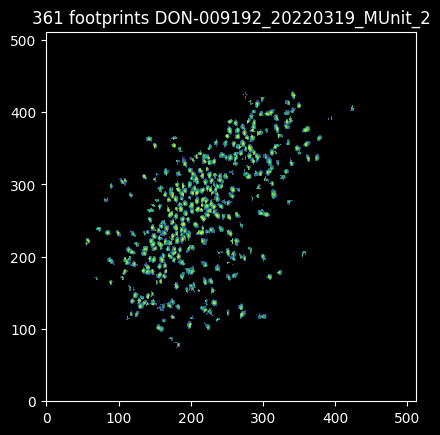

In [ ]:
# get Mask with the most not geldrying cells
try:
    del viz
except:
    pass
viz = Vizualizer(animals)
most_good_cells = 0
for unit_id, unit in units.items():
    num_good_cells = len(unit.cell_geldrying)-sum(unit.cell_geldrying)
    if num_good_cells > most_good_cells:
        most_good_cells = num_good_cells 
        best_unit = unit
best_footprints = best_unit.footprints
print(f"Best Mask has {most_good_cells} cells and is from {best_unit.unit_id}")
viz.unit_footprints(best_unit)

#TODO: Merge all footprints and deduplicate
#viz.footprints(best_footprints)

In [12]:
data_path = "F:\\Steffen_Experiments\\DON-009192\\20220319\\002P-F\\test"
fname = "data.bin"
fpath = os.path.join(data_path, fname)

[582 576 576 ... 576 576 576]


In [ ]:

#np.fromfile(mmap_mode)
traces = np.zeros([len(best_footprints), len(binary)])
for frame_num, image in enumerate(binary):
    for cell_num, footprint in enumerate(best_footprints):
        cell_area = image[footprint]
        traces[cell_num, frame_num] = sum(cell_area)

IndexError: invalid index to scalar variable.

In [97]:
image_x_size = 512
image_y_size = 512
image_size = image_x_size*image_y_size
num_frames = len(np.memmap(fpath))/image_size
n_frames_to_be_acquired = 200
binary = np.memmap(fpath,
                    dtype='uint16',
                    mode='r',
                    shape=n_frames_to_be_acquired*image_size)
images = np.reshape(binary, [n_frames_to_be_acquired, image_x_size, image_y_size])

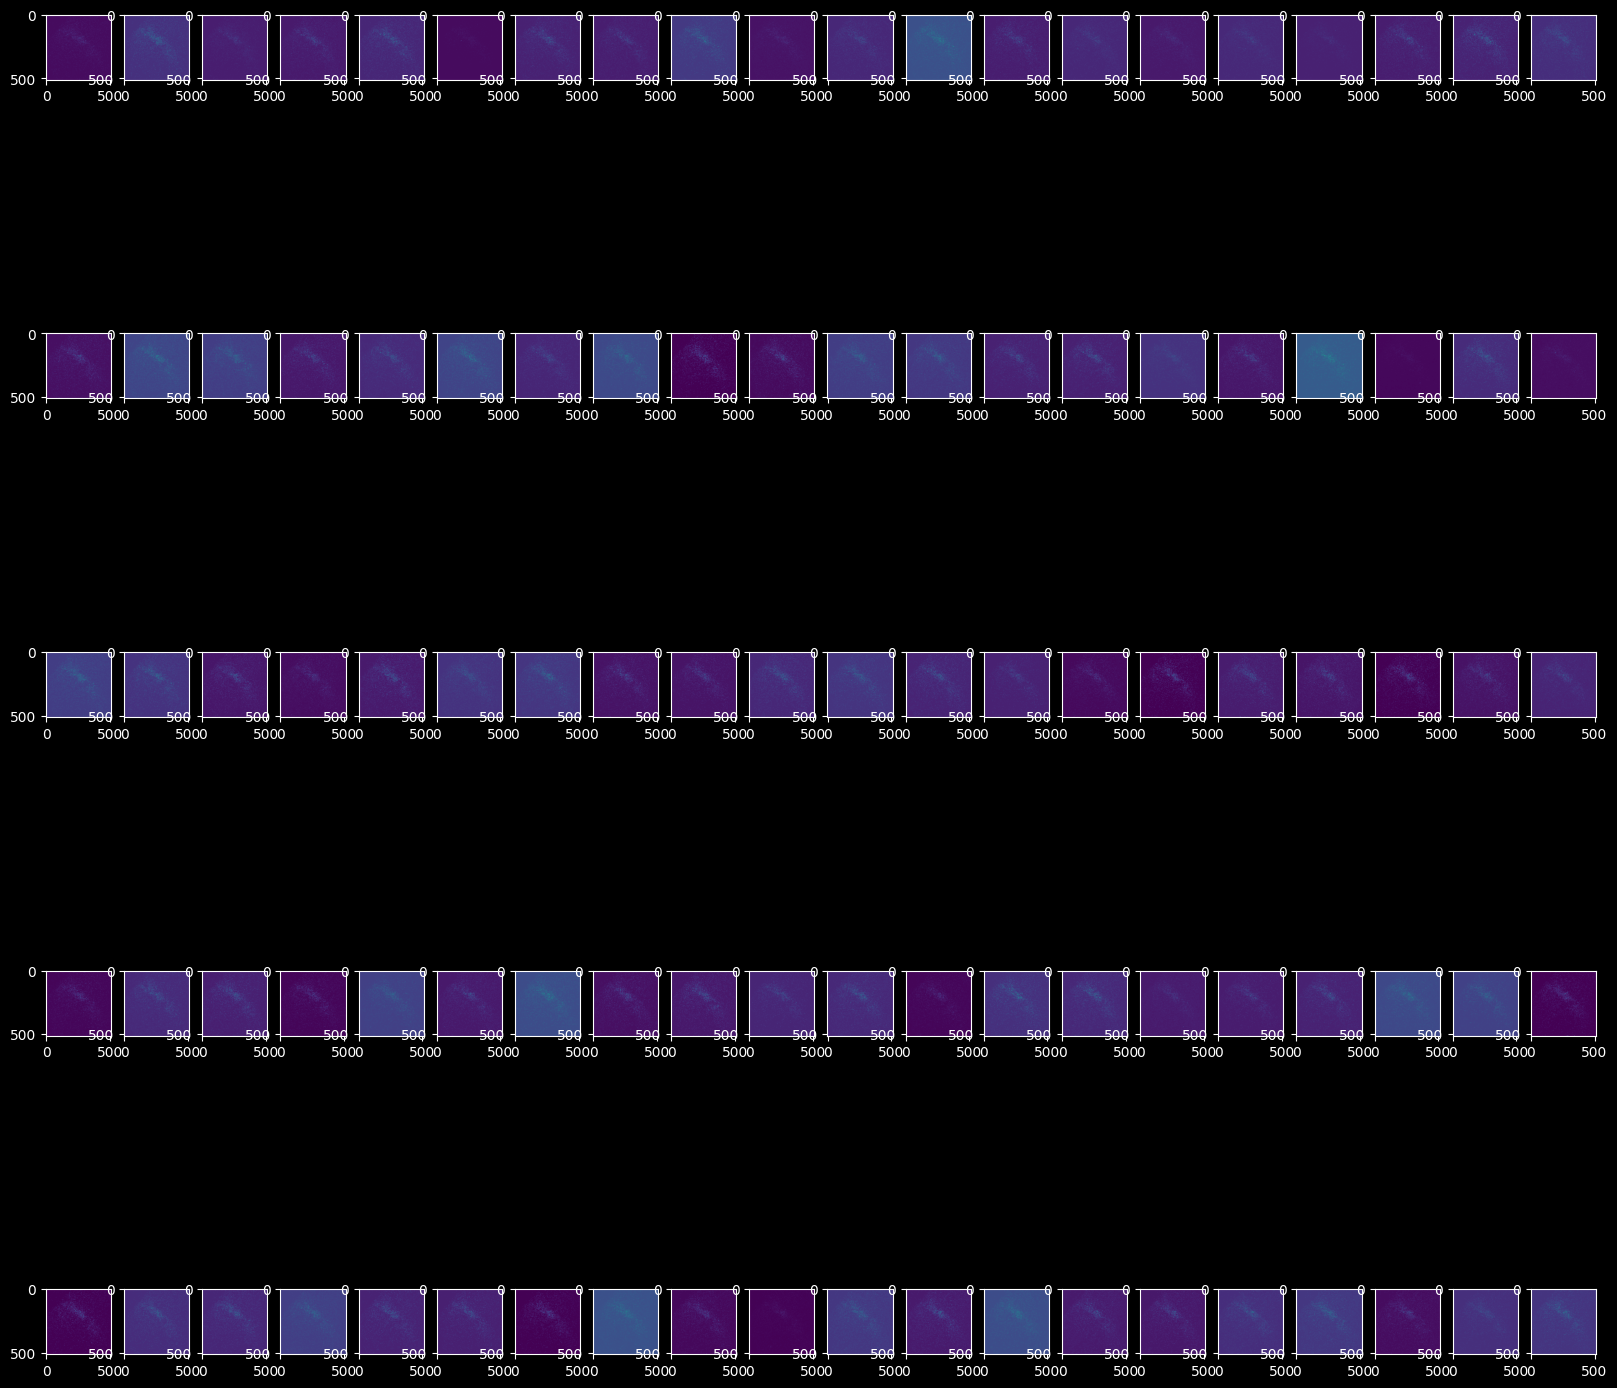

In [99]:
num_images_x = 20
fig, ax = plt.subplots(round(n_frames_to_be_acquired/num_images_x), num_images_x, figsize =(20, 20))
for i, image in enumerate(images):
    x = int(i/num_images_x)
    y = i%num_images_x
    ax[x, y].imshow(image)
#plt.show()

In [ ]:
import numpy as np
from pathlib import Path

import suite2p
from suite2p.extraction.masks import create_cell_pix, create_neuropil_masks, create_masks, create_cell_mask
from suite2p.extraction.extract import extract_traces_from_masks
from suite2p.detection import roi_stats

# Read in mask data from cellpose
cellpose_fpath = "path/to/segmented/cellpose/file/yourfile_seg.npy"
cellpose_masks = np.load(cellpose_fpath, allow_pickle=True).item()


# Read in existing data from a suite2p run. We will use the "ops" and registered binary.
wd_path = 'path/to/your/suite2p/output/folder'  # This should be the folder where processed suite2p files are saved. Consider making a backup copy of this folder before starting
wd = Path(wd_path)
ops = np.load(wd/'ops.npy', allow_pickle=True).item()
Lx = ops['Lx']
Ly = ops['Ly']
f_reg = suite2p.io.BinaryRWFile(Ly, Lx, wd/'data.bin')


# Using these inputs, we will first mimic the stat array made by suite2p
masks = cellpose_masks['masks']
stat = []
for u_ix, u in enumerate(np.unique(masks)[1:]):
    ypix,xpix = np.nonzero(masks==u)
    npix = len(ypix)
    stat.append({'ypix': ypix, 'xpix': xpix, 'npix': npix, 'lam': np.ones(npix, np.float32), 'med': [np.mean(ypix), np.mean(xpix)]})
stat = np.array(stat)
stat = roi_stats(stat, Ly, Lx)  # This function fills in remaining roi properties to make it compatible with the rest of the suite2p pipeline/GUI

# Using the constructed stat file, get masks
cell_masks, neuropil_masks = create_masks(stat, Ly, Lx, ops)

# Feed these values into the wrapper functions
stat_after_extraction, F, Fneu, F_chan2, Fneu_chan2 = suite2p.extraction_wrapper(stat, f_reg, f_reg_chan2 = None,ops=ops)

# Do cell classification
classfile = suite2p.classification.builtin_classfile
iscell = suite2p.classify(stat=stat_after_extraction, classfile=classfile)

# Apply preprocessing step for deconvolution
dF = F.copy() - ops['neucoeff']*Fneu
dF = suite2p.extraction.preprocess(
        F=dF,
        baseline=ops['baseline'],
        win_baseline=ops['win_baseline'],
        sig_baseline=ops['sig_baseline'],
        fs=ops['fs'],
        prctile_baseline=ops['prctile_baseline']
    )
# Identify spikes
spks = suite2p.extraction.oasis(F=dF, batch_size=ops['batch_size'], tau=ops['tau'], fs=ops['fs'])


# Overwrite files in wd folder (consider backing up this folder first)
np.save(wd/'F.npy', F)
np.save(wd/'Fneu.npy', Fneu)
np.save(wd/'iscell.npy', iscell)
np.save(wd/'ops.npy', ops)
np.save(wd/'spks.npy', spks)
np.save(wd/'stat.npy', stat)

KeyboardInterrupt: 